<a href="https://colab.research.google.com/github/a-forty-two/EY-MarApr26/blob/main/04_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Tips




### Step 1. Import the necessary libraries:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Step 2. Read the dataset

In [6]:
path = 'https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Tips/tips.csv'
tips_main = pd.read_csv(path)

tips_main.head()

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4


### Step 3. Check for nulls and plot a heatmap

In [7]:
tips_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  244 non-null    int64  
 1   total_bill  244 non-null    float64
 2   tip         244 non-null    float64
 3   sex         244 non-null    object 
 4   smoker      244 non-null    object 
 5   day         244 non-null    object 
 6   time        244 non-null    object 
 7   size        244 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 15.4+ KB


In [8]:
tips = tips_main.iloc[ : , 1: ]
tips.head(6)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4


<Axes: >

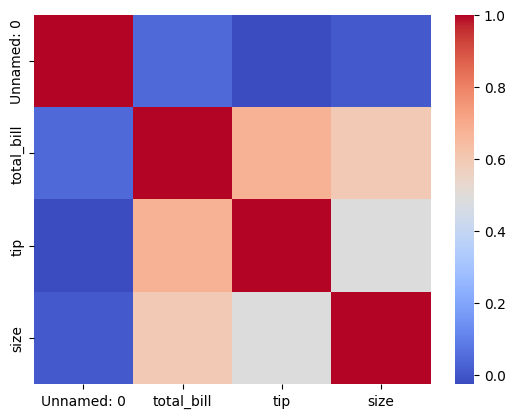

In [16]:
# Approach 1 : select only numerical columns
cols_to_select = ['Unnamed: 0','total_bill', 'tip', 'size']
stats = tips_main[cols_to_select].corr()
sns.heatmap(stats, cmap='coolwarm')

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,1,0,1,1,2
1,1,10.34,1.66,2,0,1,1,3
2,2,21.01,3.50,2,0,1,1,3
3,3,23.68,3.31,2,0,1,1,2
4,4,24.59,3.61,1,0,1,1,4


<Axes: >

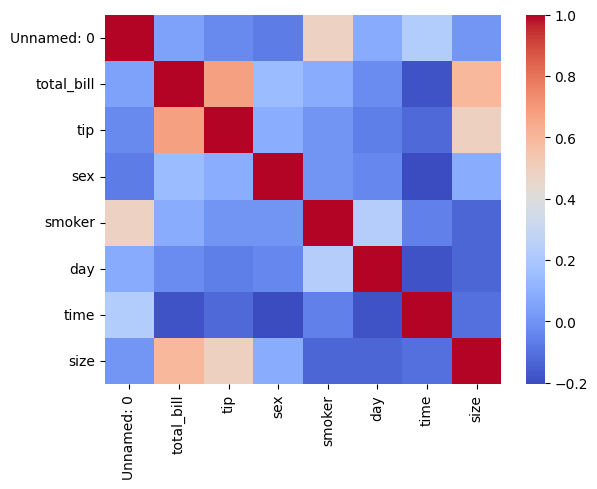

In [24]:
# Approach 2-> convert string values into columns

# A: i could have taken list comprehensions, done the conversion, and created a new dataset

# B: I could take a common conversion logic and apply to every row

# Lambda functions -> are 1 LINE FUNCTIONS!

gender_vals = {'Female':1,'Male':2}
tips_2 = tips_main.copy()
tips_2['sex'] = tips_main['sex'].apply(lambda val: gender_vals[val])
smoker_vals = {'No':0,'Yes':1}
tips_2['smoker']= tips_main['smoker'].apply(lambda val: smoker_vals[val])

day_vals = set(tips_main['day'])
day_vals = dict(zip(day_vals, range(1,len(day_vals)+1)))
tips_2['day'] = tips_main['day'].apply(lambda val: day_vals[val])

time_vals = set(tips_main['time'])
time_vals = dict(zip(time_vals, range(1,len(time_vals)+1)))
tips_2['time'] = tips_main['time'].apply(lambda val: time_vals[val])

smoker_vals = {'No':0,'Yes':1}
tips_2['smoker']= tips_main['smoker'].apply(lambda val: smoker_vals[val])

tips_2.head()


stats = tips_2.corr()
sns.heatmap(stats, cmap='coolwarm')

Question- why don't we see other columns?

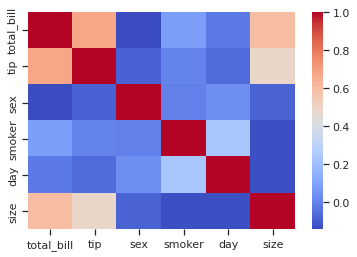

In [ ]:
# Hardcoded way -> may work 1 time, but in future when data changes,
# you will need to build your program again!

tips_copy = tips.copy()
tips_copy['sex'] = tips_copy['sex'].apply(
    lambda val: 1 if val=='Female' else 0
)
tips_copy['smoker'] = tips_copy['smoker'].apply(
    lambda val: 0 if val=='No' else 1
)
days = {'Sun':1, 'Thur':2, 'Fri':3, 'Sat':4}
tips_copy['day'] = tips_copy['day'].apply(
    lambda val: days[val]
)
stats = tips_copy.corr()
sns.heatmap(stats, cmap='coolwarm')

### Step 4. Delete the Unnamed 0 column

In [ ]:
# we have already fixed this earlier, no need to do again
#tips = tips.iloc[:, 1:]

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Step 5. Plot the total_bill column's distribution

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


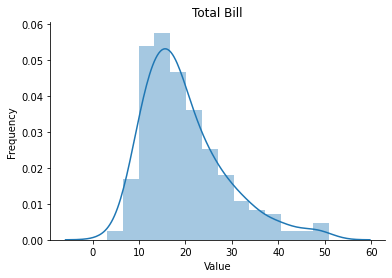

In [ ]:
totalbill = sns.distplot(tips.total_bill);
totalbill.set(xlabel = 'Value', ylabel = 'Frequency', title = "Total Bill")
sns.despine()

### Step 6. Create a scatter plot presenting the relationship between total_bill and tip

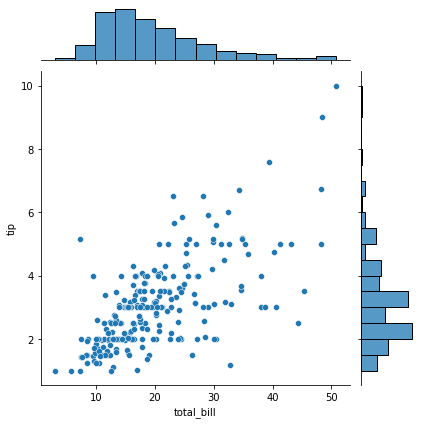

In [ ]:
sns.jointplot(x ="total_bill", y ="tip", data = tips)

### Step 7.  Create one image with the relationship of total_bill, tip and size.
#### Hint: It is just one function.

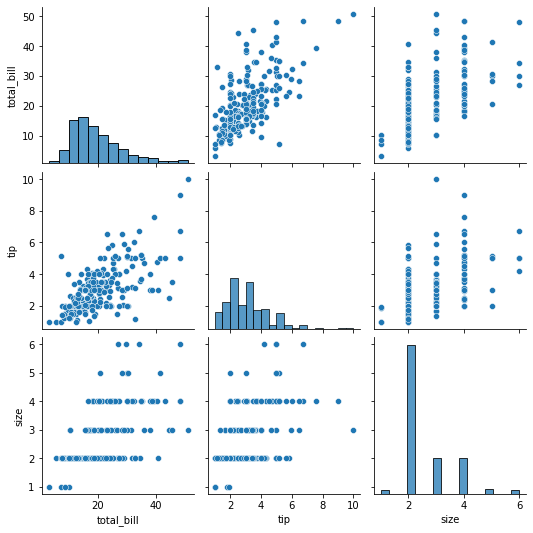

In [ ]:
sns.pairplot(tips)

### Step 8. Present the relationship between days and total_bill value

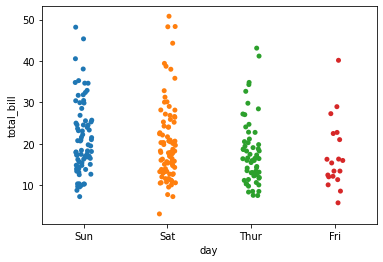

In [ ]:
sns.stripplot(x = "day", y = "total_bill", data = tips, jitter = True);

### Step 9. Create a scatter plot with the day as the y-axis and tip as the x-axis, differ the dots by sex

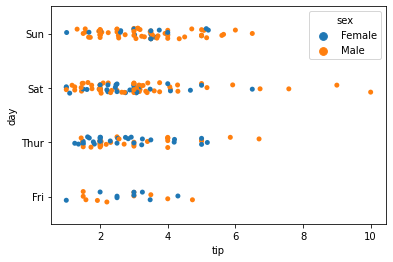

In [ ]:
sns.stripplot(x = "tip", y = "day", hue = "sex", data = tips, jitter = True);

### Step 10.  Create a box plot presenting the total_bill per day differetiation the time (Dinner or Lunch)

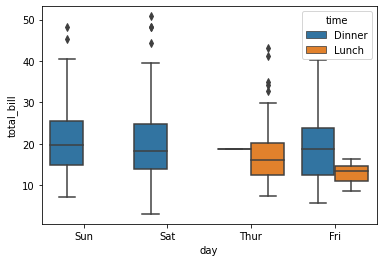

In [ ]:
sns.boxplot(x = "day", y = "total_bill", hue = "time", data = tips);

Do you see any outliers?

### Step 11. Create two histograms of the tip value based for Dinner and Lunch. They must be side by side.

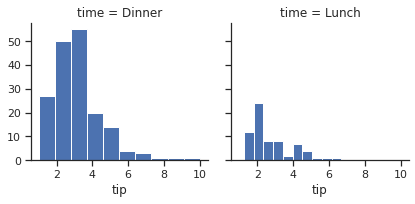

In [ ]:
# better seaborn style
sns.set(style = "ticks")

# creates FacetGrid
g = sns.FacetGrid(tips, col = "time")
g.map(plt.hist, "tip");

### Step 12. Create two scatterplots graphs, one for Male and another for Female, presenting the total_bill value and tip relationship, differing by smoker or no smoker
### They must be side by side.

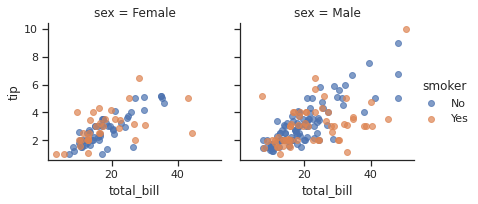

In [ ]:
g = sns.FacetGrid(tips, col = "sex", hue = "smoker")
g.map(plt.scatter, "total_bill", "tip", alpha =.7)

g.add_legend();